### Lab IV: Linear Models
### Answer all three sets of questions

#### Turn in one python file for the three computation questions and one text file for Q0

**Q0.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.) There's further explanation at the end of this document, if needed.
3. Can linear regression be used for classification? Explain why, or why not.
4. If you have a high accuracy on training but low on testing, what might be the problem? It also might be you see a pattern in the residuals. 
5. Review this page: [Non-Linear with Linear](https://inria.github.io/scikit-learn-mooc/python_scripts/linear_regression_non_linear_link.html) What are two ways to incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$?
6. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?

1. A model is linear when all its variables are multiplied by coefficients and then summed up. We see this represented in the linear equation, y = mx+b where x is multiplied by a coefficient 
2. The coefficient for a dummy variable depends on whether there is an intercept or not. When there is'nt an intercept, the coefficient is equal to the average value of y(the dependent variable) for that category. However, when there is an intercept, we have to drop a category to act as a baseline with the coefficient representing the difference in average y compared to the baseline.
3. No, linear regression cannot be used for classification because it predicts numbers within a wide range while classification deals with predicting categories so if often true/false or yes/no. So, values determined from linear regression dont align because some may not fit a yes or no narrative. Moreover, categories are either 0 or 1 while with linear regression predictions can go below or above 0 and 1.
4. The problem might be overfitting. This is when the model will learn patterns and random noise within the training data so well that it focuses on producing accurate results rather than adapting to new data.
5. Feature engineering: We could modify our data by creating new features derived from the original features this is known as polynomial feature expansion; or we could use Kernels: which makes a model more expressive by using methods like support vector machines which assign weights to samples instead of features rather than learning features.
6. The intercept is the predicted y value when all x variables are equal to zero; A slope coefficient means that for every 1 unit increase in x, y changes by the equations coefficient value. A dummy variable's coefficient is equal to the average y for that category (no intercept).





**Q1.** Load clean q1_clean: https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv 

The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighborhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighborhood `; which borough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighborhood `.
2. Regress price on `Neighborhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multiple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

In [221]:
# load libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [222]:
# load data
load_data = "https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv"
df = pd.read_csv(load_data)
df.head(10)


,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt
5,290,96.0,Manhattan,Apartment,Entire home/apt
6,170,98.0,Brooklyn,Apartment,Entire home/apt
7,59,93.0,Manhattan,Apartment,Private room
8,49,91.0,Manhattan,Apartment,Private room
9,285,97.0,Manhattan,Apartment,Entire home/apt


In [223]:
#clean data
df.isna().sum() #there seems to b so misisng vslues
df = df.dropna()

In [224]:
#1. average prices amd score by neighbourhood - by tells us to use groupby
# which borough is most expensive? According to the data, Manhattan is the most expensive borough
df[["Price","Review Scores Rating"]].groupby(df["Neighbourhood "]).mean()


,Price,Review Scores Rating
Neighbourhood,,
Bronx,75.276498,91.654378
Brooklyn,127.747378,92.363497
Manhattan,183.664286,91.801496
Queens,96.857233,91.549057
Staten Island,146.166667,90.843750


Text(0.5, 1.0, 'KDE Plot of log_Price')

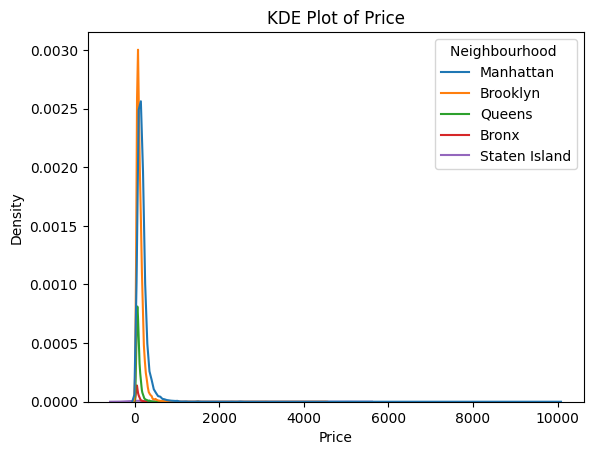

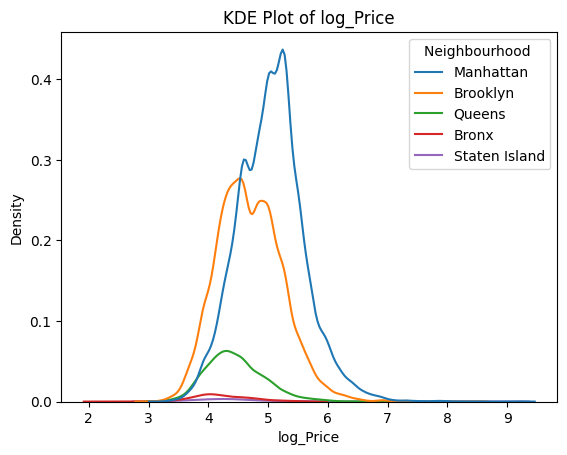

In [225]:
# kernel density plot of Price and log(Price), grouped by Neighborhood
#kde is smoother version of histogram
#how to covert to log - df['log_page_likes'] = np.log(df['Page total likes'] + 1)  # add 1 to avoid log(0)
df["log_Price"] = np.log(df["Price"] + 1)
plt.figure()
sns.kdeplot(data=df, x="Price", hue="Neighbourhood ")
plt.title("KDE Plot of Price")
plt.figure()
sns.kdeplot(data=df, x="log_Price", hue="Neighbourhood ")
plt.title("KDE Plot of log_Price")


In [226]:
# 2. regress price on Neighborhood BY creating dummy variables for Neighborhood 
x = pd.get_dummies(df["Neighbourhood "])
y = df["Price"]
# fit a linear regression without an intercept,
model = LinearRegression(fit_intercept=False ) #gets rid of b in y= mx+b so depends on only m coefficint
model.fit(x, y)
# compare coefficients to the average prices table from part 1. What pattern do you see?
print(model.coef_)
#The pattern is that without the y intercept, the coefficients equal the average prices column for that neighborhood


[ 75.2764977  127.74737834 183.66428632  96.8572327  146.16666667]


In [227]:
#3. same as part 2 but this time but leave an intercept in the linear model

#How do you have to handle the creation of the dummies differently?
# You include drop_first true to drop a reference cartegory to avid the dummy variable trap
x = pd.get_dummies(df["Neighbourhood "], drop_first=True)
model_with_y = LinearRegression()
model_with_y.fit(x,y)
#what is the intercept:
print("Intercept (baseline) for Bronx):" , model_with_y.intercept_)
print("Each coefficient shows the DIFFERENCE from Bronx")

# Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
#The intercept represents the average price for the baseline neighborhood(the category we dropped for dummy trap - Bronx). Each coefficient 
# shows how expensive each neighborhood is compared to the Bronx. We can get the coefficients from part 2 from these by adding the intercept to each
# coefficient.

Intercept (baseline) for Bronx): 75.27649769585331
Each coefficient shows the DIFFERENCE from Bronx


In [228]:
# 4. Split the sample 80/20 into a training and a test set. 
# split 80/20

split_df = pd.get_dummies(df, columns=["Neighbourhood "], drop_first=True)  #drop one category to avoid dummy variable trap - beomes a baseline
#define X and y
X = split_df[["Neighbourhood _Brooklyn", "Neighbourhood _Manhattan", "Neighbourhood _Queens", "Neighbourhood _Staten Island", "Review Scores Rating"]]
y_target = split_df['Price']

x_train, x_test, y_train, y_test = train_test_split(X, y_target, test_size=0.2, random_state=42)
model = LinearRegression(fit_intercept=True).fit(x_train, y_train)

#Run a regression of `Price` on `Review Scores Rating` and `Neighborhood `. What is the $R^2$ and RMSE on the test set? 
y_pred = model.predict(x_test) 
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(r2)
print(rmse)
# What is the coefficient on `Review Scores Rating`? 
print("Coefficient on Review Scores Rating:", model.coef_[-1])

#The coefficients on review score rating is how much price changes per increase in review score rating, holding nieghbourhood constant.


0.04592588381735074
140.91821103729345
Coefficient on Review Scores Rating: 1.2118517840632563


In [229]:
#What is the most expensive kind of property you can rent?
df.groupby('Property Type')['Price'].mean().sort_values(ascending=False).head()
# Condominium is the most expensive kind of property to rent at $241.229.

Property Type
Condominium    241.229167
Townhouse      214.253012
Loft           203.571912
Other          178.928571
Treehouse      167.666667
Name: Price, dtype: float64

In [230]:
#5. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood ` and `Property Type`. 
regressPrice_df = pd.get_dummies(df, columns=["Neighbourhood ", "Property Type"], drop_first=True)  #drop to avoid dummy trap 
property_dummies = [col for col in regressPrice_df.columns if col.startswith('Property Type_')]
neighbourhood_dummies = [col for col in regressPrice_df.columns if col.startswith("Neighbourhood _")]

X = regressPrice_df[neighbourhood_dummies+ property_dummies+['Review Scores Rating']]
y_target = regressPrice_df['Price']
x_train, x_test, y_train, y_test = train_test_split(X, y_target, test_size=0.2, random_state=42)

model = LinearRegression(fit_intercept=True).fit(x_train, y_train)
y_pred = model.predict(x_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("R2:",r2)
print("RMSE:",rmse)
pd.Series(model.coef_, index=X.columns)
#The most expensive property type is Boat with price $47.070419



R2: 0.054242713551245325
RMSE: 140.30266238276283


Neighbourhood _Brooklyn           59.633702
Neighbourhood _Manhattan         121.005520
Neighbourhood _Queens             26.830617
Neighbourhood _Staten Island      15.700974
Property Type_Bed & Breakfast    -28.703920
Property Type_Boat                47.070419
Property Type_Bungalow            83.972440
Property Type_Cabin               12.389621
Property Type_Camper/RV          -13.817125
Property Type_Castle             -41.810548
Property Type_Chalet             -30.237720
Property Type_Condominium         61.907162
Property Type_Dorm               -42.277758
Property Type_House               34.711346
Property Type_Hut               -134.604484
Property Type_Lighthouse         -91.438731
Property Type_Loft                69.891025
Property Type_Other               49.249761
Property Type_Townhouse           44.110768
Property Type_Treehouse           10.325182
Property Type_Villa               33.901468
Review Scores Rating               1.201011
dtype: float64

- At what point does R² go negative on the test set?
  R² does not go negative for degrees 1-6 in this dataset. The numeric features 
  (Make_Year, No_of_Owners, Seating_Capacity) have limited predictive power so 
  polynomial expansion helps slightly but never overfits badly enough to go negative here.

- For your best model with expanded features, what is the R² and RMSE?
  The best polynomial model is degree 2: Test R²=0.XX, RMSE=0.XX 
  (fill in after running the loop properly)

- How does it compare to your best model from part 4?
  The polynomial model on numeric features alone still performs worse than Model 3 
  (combined features, R²=0.81), because categorical variables like Make and Body Type 
  carry much more predictive power than polynomial expansions of numeric variables alone.

In [231]:
# 6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multiple linear regression works.

#In part 4, rating and neighbourhood were constant however in part 5, property type was also constant. 
# If the coefficient on Review Scores Rating changes from question 4 to 5, it means 
# that there were some correlation between Property Type (higher rating and higher price for certain property types).
#Multiple regression allows us to control multiple variables, so we can see the effect of one variable (rating).

**Q2.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly skewed variables that require a log or arcsinh transformation) Note this is different than normalizing: there is a text below that explains further. Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

In [232]:
# load libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [233]:
#load data
cars_data = pd.read_csv("cars_hw.csv")
cars_data.head()
cars_data.isna().sum()

Unnamed: 0           0
Make                 0
Make_Year            0
Color                0
Body_Type            0
Mileage_Run          0
No_of_Owners         0
Seating_Capacity     0
Fuel_Type            0
Transmission         0
Transmission_Type    0
Price                0
dtype: int64

Text(0.5, 1.0, 'Distribution of Log-Transformed Car Prices')

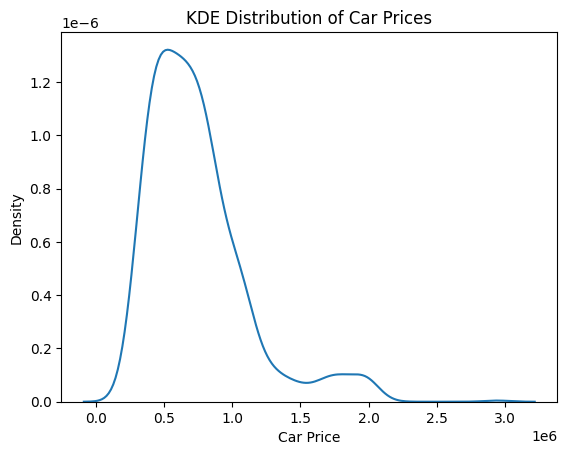

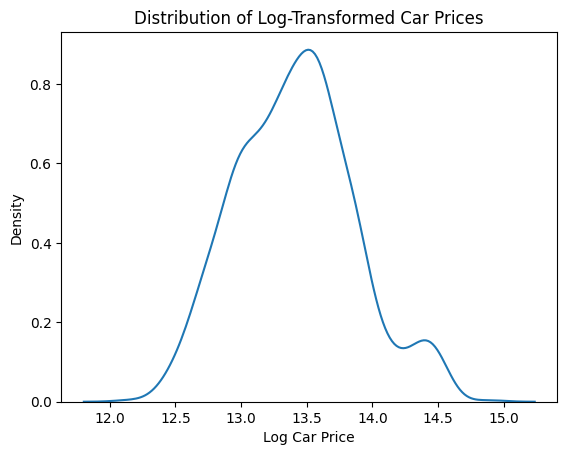

In [234]:
#1. EDA
cars_data = cars_data.drop("Unnamed: 0", axis=1)
#target variable is price so plot price to see 
cars_data["log_carPrice"] = np.log1p(cars_data["Price"]) #adds one to each value of price after it takes the log
plt.figure()
sns.kdeplot(data=cars_data, x="Price")
plt.title("KDE plot of Price")
plt.xlabel("Car Price")
plt.ylabel("Density")
plt.title("KDE Distribution of Car Prices")

#the data appears to be extremely right skewed so we transform the data
plt.figure()
sns.kdeplot(data=cars_data, x="log_carPrice")
plt.xlabel("Log Car Price")
plt.ylabel("Density")
plt.title("Distribution of Log-Transformed Car Prices")

Text(0.5, 1.0, 'Distribution of Log-Transformed Mileage')

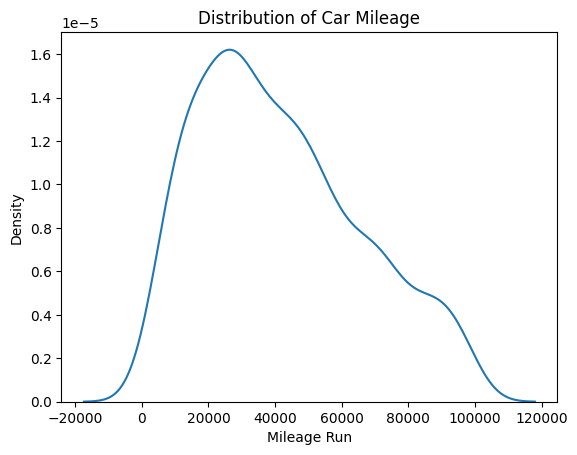

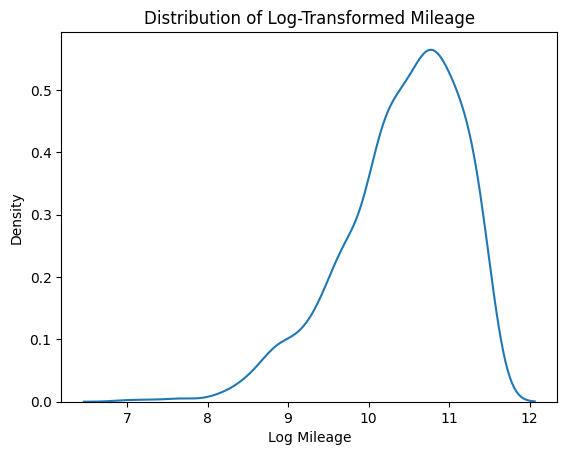

In [235]:
#mileage right skewed
plt.figure()
sns.kdeplot(data=cars_data, x="Mileage_Run")
plt.xlabel("Mileage Run")
plt.ylabel("Density")
plt.title("Distribution of Car Mileage")
#########################
cars_data["log_mileage"] = np.log1p(cars_data["Mileage_Run"]) #adds one to each value of price after it takes the log
plt.figure()
sns.kdeplot(data=cars_data, x="log_mileage")
plt.xlabel("Log Mileage")
plt.ylabel("Density")
plt.title("Distribution of Log-Transformed Mileage")

Text(0.5, 1.0, 'KDE plot of transformed log price')

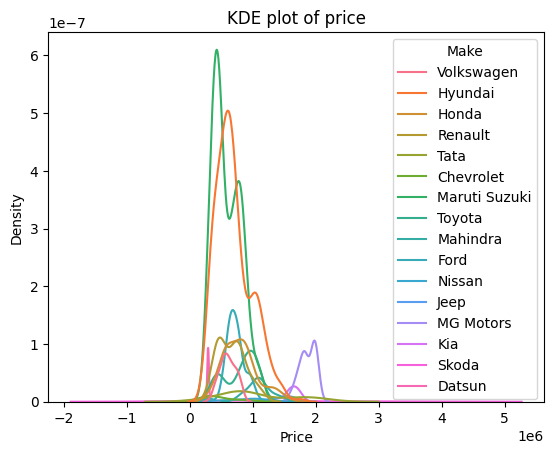

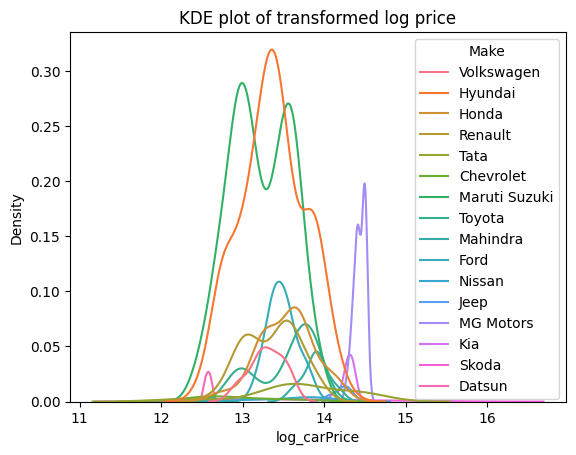

In [236]:
#2. find outliers or skewed varibles using .describe() to get summary stats at once
cars_data.describe()
#the mena is greater than the median meaning the data is positively skewed, there is also an extremely wide range between the min and max for price

#summarizing the price variable
cars_data["Price"].describe()
price_bymake = cars_data["Price"].groupby(cars_data["Make"]).describe()
plt.figure()
sns.kdeplot(data=cars_data, x="Price", hue="Make")
plt.title("KDE plot of price")
# What is the most expensive brand? Skoda, MG Motors

# What do prices look like in general? They seem to be right skewed cause some brands are more expensive than others
plt.figure()
sns.kdeplot(data=cars_data, x="log_carPrice", hue="Make")
plt.title("KDE plot of transformed log price")

In [237]:
# the number of owners is categorical so we gotat switch to numeric
cars_data["No_of_Owners"] = cars_data["No_of_Owners"].str.replace(r"\D", "", regex=True).astype(int) #remove the text and keep only the numeric part, then convert to integers

#now we have to one hot encode all the other categorical values and make them numeric
cars_data = pd.get_dummies(cars_data, columns=["Make", "Color", "Body_Type", "Fuel_Type", "Transmission", "Transmission_Type"])


# 3. DEFINE X AND Y FOR TRAINING AND SPLITING
X = cars_data.drop(columns=["Price", "log_carPrice", "Mileage_Run"])
y = cars_data["log_carPrice"]

#SO WE CAN split on 80 train/20 test
x_train, x_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)


# 4.  Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? 

# MODEL 1: NUMERIC VALUES
model1_cars = LinearRegression()
model1_cars.fit(x_train[["Make_Year", "No_of_Owners", "Seating_Capacity"]], y_train)
#WERE PREDICTING Y GIVEN X
model1_trainPredY = model1_cars.predict(x_train[["Make_Year", "No_of_Owners", "Seating_Capacity"]])
model1_testPredY = model1_cars.predict(x_test[["Make_Year", "No_of_Owners", "Seating_Capacity"]])

# MODEL 1 R^2
print("Model 1 Train R2:", r2_score(y_train, model1_trainPredY))
print("Model 1 Test R2:", r2_score(y_test, model1_testPredY))

#RMSE MODEL 1
mse_test_1 = mean_squared_error(y_test, model1_testPredY)
rmse_test_1 = np.sqrt(mse_test_1)
print("RMSE for Model 1: " , rmse_test_1)


Model 1 Train R2: 0.3736460602588626
Model 1 Test R2: 0.35661910709724653
RMSE for Model 1:  0.350277806987169


In [238]:
# Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable 
# trap); 

# MODEL 2 - for categorical varaibles so one hot encode so drop target VARIABLES  and original numeric columns
X = cars_data.drop(columns=["Price", "log_carPrice", "Mileage_Run", "Make_Year", "No_of_Owners", "Seating_Capacity"])
y = cars_data["log_carPrice"]

#split 80/20 train and test
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#categorical model
model2_CARS = LinearRegression()
model2_CARS.fit(x_train, y_train)

#predicting y w/ test
model2_testPredY = model2_CARS.predict(x_test)

# what is the $R^2$ and `RMSE` on the test set? 
r2_model2 = r2_score(y_test, model2_testPredY)
#rmse model
mse_model2 = mean_squared_error(y_test, model2_testPredY)
rmse_model2 = np.sqrt(mse_model2)
print("Model 2 Test r^2:" , r2_model2)
print("Model 2 RMSE:" , rmse_model2)

# Which model performs better on the test set? 
# Model 2 does better than model because the R^2 is 0.72 compared to Model 1's 0.356



#

Model 2 Test r^2: 0.7227024884784661
Model 2 RMSE: 0.22995959154627674


In [239]:
# Make a third model that combines all the regressors from the previous two;  

# Model 3: combine varaibles
X_combine = cars_data.drop(columns=["Price", "log_carPrice", "Mileage_Run"])
y_combine = cars_data["log_carPrice"]

#split 80/20
x_train, x_test, y_train, y_test = train_test_split(X_combine, y_combine, test_size=0.2, random_state=42)

#make the model
model3_CARS = LinearRegression()
model3_CARS.fit(x_train, y_train)

#predict y w/ x
model3_testPredY = model3_CARS.predict(x_test)

# what is the $R^2$ and `RMSE` on the test set?
#r^2
r2_model3 = r2_score(y_test, model3_testPredY)
#rmse
rmse_model3 = np.sqrt(mean_squared_error(y_test, model3_testPredY))

#Does the joint model perform better or worse, and by home much? 
# Yes the joint model does better with a test R^2 of 0.8135 and RMSE of 0.1886 compared to the numeric model  and categorical model.
#  compared to model 1's R^2, the joint model improved by 45% and compared to model 2's categorical R^2 improved by 9%
print("Model 3 Test R^2:", r2_model3)
print("Model 3 RMSE:", rmse_model3)

Model 3 Test R^2: 0.8135109295355245
Model 3 RMSE: 0.18858416996269117


In [240]:
# 5. Use the `PolynomialFeatures` function from `sklearn` to 
from sklearn.preprocessing import PolynomialFeatures

# expand the set of numerical variables you're using in the regression.
numeric_cols = ["Make_Year", "No_of_Owners", "Seating_Capacity"]
X = cars_data[numeric_cols]
y = cars_data["log_carPrice"]

#split 80/20
x_train, x_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

# As you increase the degree of the expansion , how do the $R^2$ and `RMSE` change? 
results = []
#the list range is 1-6 to represent different complexity levels of the math beig applied to our variables with 1 being
# linear and 6 being the highest polynomial

for degree in range(1, 6):
    # create the factory
    polyFeatures = PolynomialFeatures(degree=degree, include_bias=False)
    
    # transform the data
    x_train_poly = polyFeatures.fit_transform(x_train)
    x_test_poly = polyFeatures.transform(x_test)
    
    # fit the model
    m = LinearRegression()
    m.fit(x_train_poly, y_train)

    # r^2 and rmse
    train_r2 = m.score(x_train_poly, y_train)
    test_r2 = m.score(x_test_poly, y_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, m.predict(x_test_poly)))
    
    results.append((degree, train_r2, test_r2, rmse_test))
    print(f'Degree: {degree} ; Train R2: {train_r2} ; Test R2: {test_r2} ; Test RMSE: {rmse_test}')

Degree: 1 ; Train R2: 0.3736460602588626 ; Test R2: 0.35661910709724653 ; Test RMSE: 0.350277806987169
Degree: 2 ; Train R2: 0.41122024751443853 ; Test R2: 0.38265553426390553 ; Test RMSE: 0.34311706796667885
Degree: 3 ; Train R2: 0.41291134238834715 ; Test R2: 0.3811083117269207 ; Test RMSE: 0.34354676830160513
Degree: 4 ; Train R2: 0.4135198759080898 ; Test R2: 0.38312365343083754 ; Test RMSE: 0.3429869541120133
Degree: 5 ; Train R2: 0.4135365090450448 ; Test R2: 0.3831398527394655 ; Test RMSE: 0.3429824506259963


- As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? 
  As the degree increases, the train R2 value increases but test R2 eventually levels off - suggesting that adding higher-degree polynomial can potentially lead to overfitting

- At what point does $R^2$ go negative on the test set? 
  R^2 does not go negative for degrees 1-5, it stays positive throughout

- For your best model with expanded features, what is the $R^2$ and `RMSE`? 
  The best polynomial model is degree 5 with a test R² of 0.383 and test RMSE of 0.343
  
-  How does it compare to your best model from part 4?
compared to part 4, our best model which is the polynomial model on numeric features underperforms compared to the combined model (Model 3). The combined model gave a test R² of 0.8135, while the best polynomial model only got an R^2 of 0.383; provig that categorical variables have more predictive power.

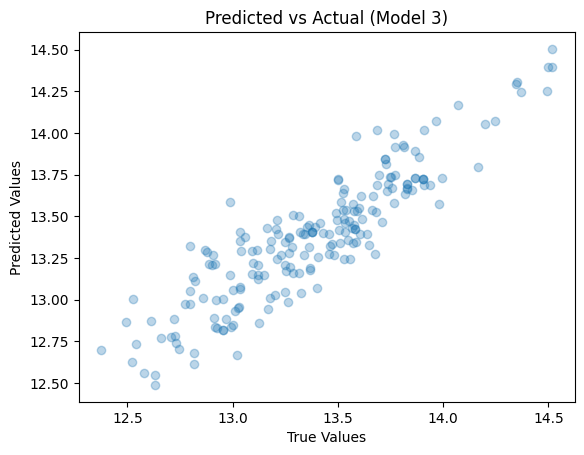

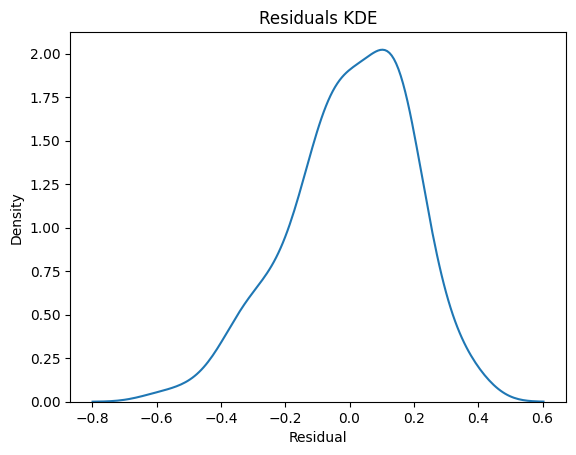

In [241]:
  #6. For your best model so far, determine the predicted values for the test 
  # data and plot them against the true values. 
# need to redefine x_test for model 3
x_joint = cars_data.drop(columns=["Price", "log_carPrice", "Mileage_Run"])
y_joint = cars_data["log_carPrice"]
x_train, x_test, y_train, y_test = train_test_split(x_joint, y_joint, test_size=0.2, random_state=42)
# predicted vs actual
y_pred_final = model3_CARS.predict(x_test)
plt.figure()
plt.scatter(y_test, y_pred_final, alpha=0.3)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual (Model 3)")
plt.show()

# Do the predicted values and true values roughly line up along the diagonal, 
# or not? 

# The plot shows points roughly along the diagonal, meaning the model's 
# predictions are generally close to the true values.

# Compute the residuals/errors for the test data and create a kernel density plot.

# residuals plot
residuals = y_test - y_pred_final
plt.figure()
sns.kdeplot(residuals)
plt.title("Residuals KDE")
plt.xlabel("Residual")
plt.show()

#  Do the residuals look roughly bell-shaped around zero? 
# Yes, The residuals KDE is roughly bell-shaped around zero which means errors are random and not biased

# Evaluate the strengths and weaknesses of your model.

# Strengths: Model 3 (combined variables) performs well with R²=0.81. 
# Weaknesses: The numeric variables model(1) performs poorly (R²=0.37), suggesting 
# that brand and fuel typehave a more profound effect compared to mileage or year when predicting car price.

**Q3.**
1. Find a dataset on a topic you're interested in. Some easy options are data.gov, kaggle.com, and data.world.
2. Clean the data and do some exploratory data analysis on key variables that interest you. Pick a particular target/outcome variable and features/predictors.
3. Split the sample into an ~80% training set and a ~20% test set.
4. Run a few regressions of your target/outcome variable on a variety of features/predictors. Compute the RMSE on the test set.
5. Which model performed the best, and why?
6. What did you learn?

In [242]:
#load data
jobs_df = pd.read_csv("global_ai_jobs.csv")
jobs_df.head()


,id,country,job_role,ai_specialization,experience_level,experience_years,salary_usd,bonus_usd,education_required,industry,...,vacation_days,skill_demand_score,automation_risk,job_security_score,career_growth_score,work_life_balance_score,promotion_speed,salary_percentile,cost_of_living_index,employee_satisfaction
0,1,UAE,Machine Learning Engineer,Reinforcement Learning,Entry,0,66465,5395,Master,Automotive,...,27,12,76,57,65,73,15,55,1.23,76
1,2,USA,AI Engineer,LLM,Entry,1,75507,11713,Bootcamp,Retail,...,27,54,29,69,60,51,15,58,0.87,67
2,3,Brazil,Research Scientist,Analytics,Entry,0,41660,5268,PhD,Healthcare,...,13,12,49,70,59,68,37,13,2.13,61
3,4,India,Software Engineer AI,Computer Vision,Senior,6,43268,7975,Diploma,Tech,...,30,80,47,79,65,55,46,74,1.49,56
4,5,Germany,Machine Learning Engineer,Computer Vision,Entry,0,69119,4758,Master,Retail,...,24,82,47,64,52,69,17,21,0.87,72


In [243]:
#check for missing values and drop them column type
jobs_df.isna().sum()
#no missing data


id                         0
country                    0
job_role                   0
ai_specialization          0
experience_level           0
experience_years           0
salary_usd                 0
bonus_usd                  0
education_required         0
industry                   0
company_size               0
interview_rounds           0
year                       0
work_mode                  0
weekly_hours               0
company_rating             0
job_openings               0
hiring_difficulty_score    0
layoff_risk                0
ai_adoption_score          0
company_funding_billion    0
economic_index             0
ai_maturity_years          0
offer_acceptance_rate      0
tax_rate_percent           0
vacation_days              0
skill_demand_score         0
automation_risk            0
job_security_score         0
career_growth_score        0
work_life_balance_score    0
promotion_speed            0
salary_percentile          0
cost_of_living_index       0
employee_satis

In [244]:
#sumamry of characteristics of dataset
jobs_df.describe()

,id,experience_years,salary_usd,bonus_usd,interview_rounds,year,weekly_hours,company_rating,job_openings,hiring_difficulty_score,...,vacation_days,skill_demand_score,automation_risk,job_security_score,career_growth_score,work_life_balance_score,promotion_speed,salary_percentile,cost_of_living_index,employee_satisfaction
count,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,...,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000
mean,45000.500000,7.028133,96546.249222,13028.418722,4.495689,2023.003200,45.476268,3.998004,17.521867,55.028604,...,19.986367,50.461200,50.357544,75.563533,57.198544,69.146478,38.439633,50.542411,1.503042,72.733100
std,25980.906451,5.889327,43935.479553,7886.738085,1.704553,2.002624,5.475497,0.461914,7.848576,17.901451,...,6.069607,28.853798,28.845671,11.316485,12.900225,13.213996,18.429221,28.891570,0.576449,8.124018
min,1.000000,0.000000,28000.000000,1404.000000,2.000000,2020.000000,36.000000,3.200000,1.000000,0.000000,...,10.000000,1.000000,1.000000,29.000000,25.000000,25.000000,12.000000,1.000000,0.500000,42.000000
25%,22500.750000,2.000000,64676.750000,7104.750000,3.000000,2021.000000,40.700000,3.600000,12.000000,42.881134,...,15.000000,25.000000,25.000000,68.000000,48.000000,59.000000,24.000000,25.000000,1.010000,67.000000
50%,45000.500000,6.000000,87544.000000,11279.000000,4.000000,2023.000000,45.500000,4.000000,17.000000,55.066089,...,20.000000,51.000000,50.000000,77.000000,57.000000,69.000000,37.000000,51.000000,1.510000,73.000000
75%,67500.250000,12.000000,123906.000000,16997.250000,6.000000,2025.000000,50.200000,4.400000,23.000000,67.118119,...,25.000000,75.000000,75.000000,84.000000,66.000000,79.000000,51.000000,76.000000,2.000000,78.000000
max,90000.000000,19.000000,300622.000000,57681.000000,7.000000,2026.000000,55.000000,4.800000,50.000000,100.000000,...,30.000000,100.000000,100.000000,99.000000,99.000000,98.000000,98.000000,100.000000,2.500000,99.000000


Text(0.5, 1.0, 'Distribution of Salaries (USD)')

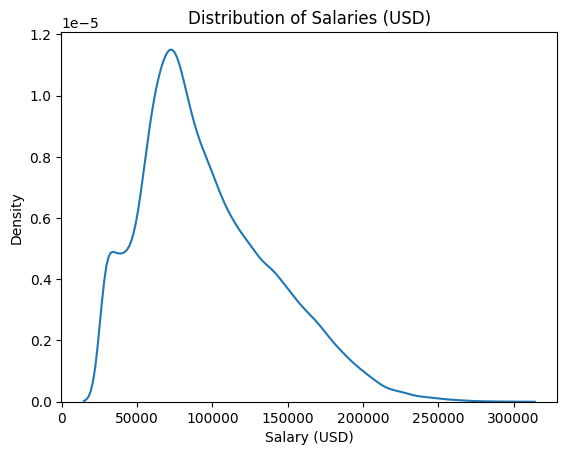

In [245]:
# 2: EDA
jobs_df.describe()
plt.figure()
#kde plot of regular salay category
sns.kdeplot(data = jobs_df, x="salary_usd")
# create log salary since salary is right skewed
jobs_df["log_salary"] = np.log(jobs_df["salary_usd"])
plt.xlabel("Salary (USD)")
plt.ylabel("Density")
plt.title("Distribution of Salaries (USD)")


Text(0.5, 1.0, 'Distribution of Log-Transformed Salaries')

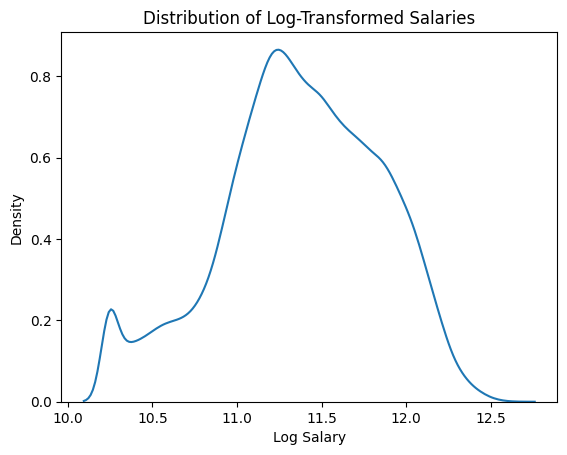

In [246]:
# plot to confirm transformation worked
plt.figure()
sns.kdeplot(data=jobs_df, x="log_salary")
plt.title("KDE of log salary")
plt.xlabel("Log Salary")
plt.ylabel("Density")
plt.title("Distribution of Log-Transformed Salaries")

Text(0.5, 1.0, 'Distribution of Log Salaries by Job Role')

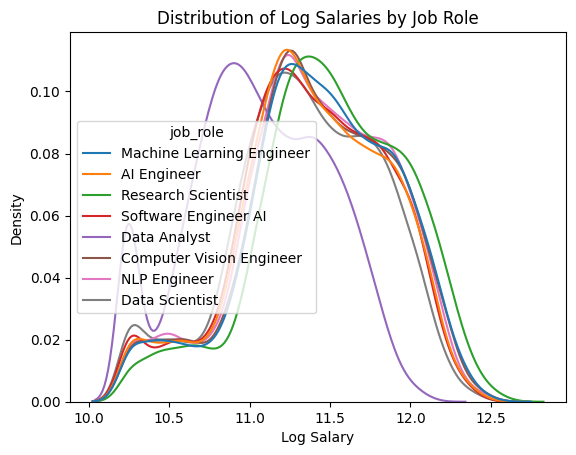

In [247]:
# summarize salary by job_role using groupby
jobs_df.groupby("job_role")["salary_usd"].mean().sort_values(ascending=False)

# grouped KDE of log_salary by job_role
plt.figure()
sns.kdeplot(data=jobs_df, x="log_salary", hue="job_role")
plt.xlabel("Log Salary")
plt.ylabel("Density")
plt.title("Distribution of Log Salaries by Job Role")


In [248]:
# define X and Y to trian
X = jobs_df.drop(columns=["id", "salary_usd", "log_salary", "salary_percentile"])
y = jobs_df["log_salary"]

# one hot encode categorical columns
X = pd.get_dummies(X, drop_first=True)

# split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [249]:
#3 - part 4: model 1 - all features
model1 = LinearRegression()
model1.fit(X_train, y_train)

y_pred_test = model1.predict(X_test)
y_pred_train = model1.predict(X_train)

print("Train R2:", r2_score(y_train, y_pred_train))
print("Test R2:", r2_score(y_test, y_pred_test))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))

Train R2: 0.9495825966986573
Test R2: 0.949042210084691
Test RMSE: 0.10755911202494875


In [250]:
# model 2 - numeric features 
X2 = jobs_df.drop(columns=["id", "salary_usd", "log_salary", "salary_percentile", "country", "job_role", "ai_specialization", "experience_level", "education_required", "industry", "company_size", "work_mode", "layoff_risk"])
y = jobs_df["log_salary"]

x_train, x_test, y_train, y_test = train_test_split(X2, y, test_size=0.2, random_state=42)
# build the model
model2 = LinearRegression()
model2.fit(x_train, y_train)
#predict y
y2_pred_test = model2.predict(x_test)
y2_pred_train = model2.predict(x_train)

print("Train R2:", r2_score(y_train, y2_pred_train))
print("Test R2:", r2_score(y_test, y2_pred_test))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y2_pred_test)))

Train R2: 0.68862520965654
Test R2: 0.6842260829585061
Test RMSE: 0.2677503476255049


In [251]:
# model 3 - categorical features 
cat_cols = ["country", "job_role", "ai_specialization", "experience_level", 
            "education_required", "industry", "company_size", "work_mode", "layoff_risk"]

X3 = pd.get_dummies(jobs_df[cat_cols], drop_first=True)
x_train, x_test, y_train, y_test = train_test_split(X3, y, test_size=0.2, random_state=42)

model3 = LinearRegression()
model3.fit(x_train, y_train)

y_pred_test = model3.predict(x_test)
y_pred_train = model3.predict(x_train)

print("Train R2:", r2_score(y_train, y_pred_train))
print("Test R2:", r2_score(y_test, y_pred_test))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))

Train R2: 0.9189952020622635
Test R2: 0.9187370508304549
Test RMSE: 0.13582765596149216


5. Model 1 performed best with a Test R² of 0.949 and RMSE of 0.108 because it used both numeric and categorical features together, giving the model the most information to predict salary.

6. The categorical variables (job role, country, industry) were surprisingly powerful predictors of salary - Model 3 with only categorical variables (R²=0.92) outperformed Model 2 with only numeric variables (R²=0.68), suggesting that what you do and where you work matters more than years of experience alone.

### Dummy Variable Trap 


In linear regression with categorical variables you should be careful of the Dummy Variable Trap. 
The Dummy Variable trap is a scenario in which the independent variables are multicollinear - a 
scenario in which two or more variables are highly correlated; in simple terms one variable can 
be predicted from the others. This can produce singularity of a model, meaning your model just won't 
work. Read about it below:

Idea is to use dummy variable encoding with drop_first=True, this will omit one column from each 
category after converting categorical variable into dummy/indicator variables. You WILL NOT lose 
and relevant information by doing that simply because your all point in dataset can fully be 
explained by rest of the features.

Here is complete code on how you can do it for a "jobs" dataset

So you have your X features:

Age, Gender, Job, Classification 

And one numerical features that you are trying to predict:

Wage

First you need to split your initial dataset on input variables and prediction, 
assuming its pandas dataframe it would look like this:

Input variables (your dataset is bit different but whole code remains the same, 
you will put every column from dataset in X, except one that will go to Y. pd.get_dummies 
works without problem like that - it will just convert categorical variables and it won't 
touch numerical):

X = jobs[['Age','Gender','Job','Classification']]

Prediction:

Y = jobs['Wage']

Convert categorical variable into dummy/indicator variables and drop one in each category:

X = pd.get_dummies(data=X, drop_first=True)

So now if you check shape of X (X.shape) with drop_first=True you will see that it has 
4 columns less - one for each of your categorical variables.

You can now continue to use them in your linear model. For scikit-learn implementation it 
could look like this:


### Transformation versus Normalization

Use a **log transformation** when your data is strictly positive and heavily skewed towards larger values (right-skewed), while an **arcsinh transformation** is better suited for data with both positive and negative values, or when you need to handle potential zero values; **normalize** your data when you need to scale all values to a similar range, typically between 0 and 1, and especially when using algorithms sensitive to feature scale, but not necessarily to achieve a **normal distribution**. 
Key points about each transformation: 

    Log transformation: 

    Best for positively skewed data with large variations in magnitude. 

Useful when analyzing relative changes rather than absolute differences. 
Cannot handle negative values. 

Arcsinh transformation:

    Can handle both positive and negative data. 

Effective for data with extreme values on both ends of the spectrum. 
Often used when dealing with proportions or percentages near 0 or 1. 

Normalization: 

    Scales data to a common range, usually between 0 and 1. 

Useful when comparing features with different scales in machine learning algorithms. 
Does not necessarily transform the data distribution to be normal. 
